# Probability of Default

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/sunil-mnair/curriculum/master/analytics_using_python/training_data.csv')

## Describe and Explore Data

In [ ]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,24642.000000,24592.000000,2.464200e+04,24642.000000,24642.000000,24642.000000,24642.000000,24642.000000,2.464200e+04,2.464100e+04,24607.000000,24633.000000
mean,310039.948705,619.961004,1.392134e+06,18892.758917,19.014512,34.591551,11.490261,0.181641,2.566727e+05,6.673054e+05,0.112976,0.037267
std,181569.321788,150.287473,6.765958e+05,11237.977101,6.636231,21.587888,4.953918,0.519299,2.871215e+05,6.634998e+06,0.349750,0.299791
min,21450.000000,300.000000,1.112450e+05,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,173651.500000,467.000000,9.236708e+05,11081.702500,14.500000,16.000000,8.000000,0.000000,1.011940e+05,2.480940e+05,0.000000,0.000000
50%,267674.000000,708.000000,1.246980e+06,17007.375000,17.700000,31.000000,11.000000,0.000000,1.860765e+05,4.198700e+05,0.000000,0.000000
75%,429852.500000,732.000000,1.712138e+06,24444.972500,22.400000,51.000000,14.000000,0.000000,3.237505e+05,6.984560e+05,0.000000,0.000000
max,789096.000000,751.000000,4.634575e+06,119621.720000,70.500000,81.000000,48.000000,15.000000,6.723017e+06,7.982554e+08,4.000000,15.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24642 entries, 0 to 24641
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan ID                       24642 non-null  object 
 1   Customer ID                   24642 non-null  object 
 2   Loan Status                   24642 non-null  object 
 3   Current Loan Amount           24642 non-null  int64  
 4   Term                          24642 non-null  object 
 5   Credit Score                  24592 non-null  float64
 6   Annual Income                 24642 non-null  int64  
 7   Years in current job          24553 non-null  object 
 8   Home Ownership                24642 non-null  object 
 9   Purpose                       24642 non-null  object 
 10  Monthly Debt                  24642 non-null  float64
 11  Years of Credit History       24642 non-null  float64
 12  Months since last delinquent  24642 non-null  int64  
 13  N

### Identify Null Value Columns

In [3]:
null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]
print("Columns with null values and their counts:")
print(null_columns)

Columns with null values and their counts:
Credit Score            50
Years in current job    89
Maximum Open Credit      1
Bankruptcies            35
Tax Liens                9
dtype: int64


### Identify Text Columns - Low Cardinality

In [4]:
low_cardinality_cols = []
for col in df.select_dtypes(include='object').columns:
    num_unique = df[col].nunique()
    if num_unique < 50:
        low_cardinality_cols.append((col, num_unique))

if low_cardinality_cols:
    print("Text columns with low cardinality (less than 50 unique values):")
    for col, count in low_cardinality_cols:
        print(f"- {col}: {count} unique values")
else:
    print("No text columns found with low cardinality (less than 50 unique values).")

Text columns with low cardinality (less than 50 unique values):
- Loan Status: 2 unique values
- Term: 2 unique values
- Years in current job: 11 unique values
- Home Ownership: 4 unique values
- Purpose: 12 unique values


### Identify Duplicate Values

In [5]:
for col, _ in low_cardinality_cols:
    print(f"\nUnique values for '{col}':")
    print(df[col].unique())


Unique values for 'Loan Status':
['Charged Off' 'Fully Paid']

Unique values for 'Term':
['Short Term' 'Long Term']

Unique values for 'Years in current job':
['< 1 year' '1 year' '10+ years' nan '2 years' '3 years' '4 years'
 '5 years' '7 years' '8 years' '9 years' '6 years']

Unique values for 'Home Ownership':
['Rent' 'Home Mortgage' 'Own Home' 'HaveMortgage']

Unique values for 'Purpose':
['Debt Consolidation' 'Other' 'Home Improvements' 'Medical Bills'
 'Business Loan' 'moving' 'Buy a Car' 'Buy House' 'vacation'
 'Educational Expenses' 'wedding' 'renewable_energy']


## Data Cleaning

### Null Value Treatment

<Axes: >

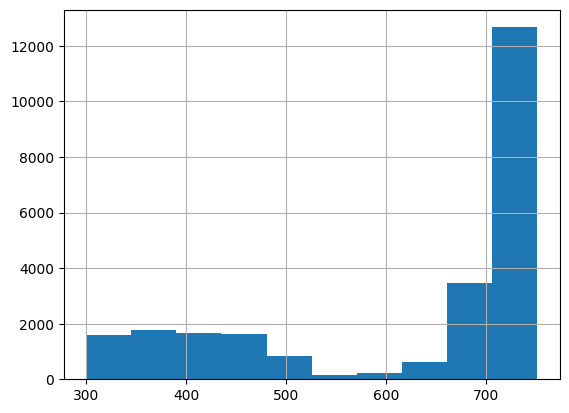

In [6]:
df["Credit Score"].hist()

In [7]:
df["Credit Score"].mean()

np.float64(619.9610035783995)

In [8]:
df["Credit Score"].median()

708.0

In [9]:
df["Years in current job"].mode()

,Years in current job
0,10+ years


In [10]:
for col in ['Credit Score', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled nulls in '{col}' with median: {median_val}")

for col in ['Years in current job']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple if tied, take the first
        df[col] = df[col].fillna(mode_val)
        print(f"Filled nulls in '{col}' with mode: {mode_val}")

# Verify that there are no more null values in these columns
print("\nVerifying null values after imputation:")
print(df[null_columns.index].isnull().sum())

Filled nulls in 'Credit Score' with median: 708.0
Filled nulls in 'Maximum Open Credit' with median: 419870.0
Filled nulls in 'Bankruptcies' with median: 0.0
Filled nulls in 'Tax Liens' with median: 0.0
Filled nulls in 'Years in current job' with mode: 10+ years

Verifying null values after imputation:
Credit Score            0
Years in current job    0
Maximum Open Credit     0
Bankruptcies            0
Tax Liens               0
dtype: int64


### Drop Unwanted Columns

In [11]:
df = df.drop(columns=['Loan ID', 'Customer ID'], axis=1)
print("Columns after dropping 'Loan ID' and 'Customer ID':")
print(df.columns)

Columns after dropping 'Loan ID' and 'Customer ID':
Index(['Loan Status', 'Current Loan Amount', 'Term', 'Credit Score',
       'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose',
       'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')


### Value Correction

In [12]:
df['Home Ownership'] = df['Home Ownership'].replace('HaveMortgage', 'Home Mortgage')
print("Unique values in 'Home Ownership' after correction:")
print(df['Home Ownership'].unique())

Unique values in 'Home Ownership' after correction:
['Rent' 'Home Mortgage' 'Own Home']


## Data Transformation and Encoding

### Encoding

In [13]:
# Ordinal encoding for 'Term'
term_mapping = {'Short Term': 0, 'Long Term': 1}
df['Term_Encoded'] = df['Term'].map(term_mapping)

# Ordinal encoding for 'Years in current job'
# Define the order for 'Years in current job'
years_in_job_order = [
    '< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
    '6 years', '7 years', '8 years', '9 years', '10+ years'
]
years_in_job_mapping = {val: i for i, val in enumerate(years_in_job_order)}

df['Years in current job_Encoded'] = df['Years in current job'].map(years_in_job_mapping)

# Columns to drop after encoding (original columns)
cols_to_drop_after_ordinal = ['Term', 'Years in current job']

# Identify columns for one-hot encoding
# Start with all object columns
object_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'Loan Status' as per request and the columns already handled by ordinal encoding
cols_for_one_hot = [col for col in object_cols if col not in ['Loan Status'] + cols_to_drop_after_ordinal]

print(f"Columns for one-hot encoding: {cols_for_one_hot}")

# Apply one-hot encoding
df = pd.get_dummies(df, columns=cols_for_one_hot, drop_first=True, dtype=int)

# Drop the original 'Term' and 'Years in current job' columns
df = df.drop(columns=cols_to_drop_after_ordinal)

# Display changes
print("\nDataFrame info after all encoding steps:")
df.info()
print("\nFirst 5 rows of the DataFrame after encoding:")
print(df.head())

Columns for one-hot encoding: ['Home Ownership', 'Purpose']

DataFrame info after all encoding steps:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24642 entries, 0 to 24641
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan Status                   24642 non-null  object 
 1   Current Loan Amount           24642 non-null  int64  
 2   Credit Score                  24642 non-null  float64
 3   Annual Income                 24642 non-null  int64  
 4   Monthly Debt                  24642 non-null  float64
 5   Years of Credit History       24642 non-null  float64
 6   Months since last delinquent  24642 non-null  int64  
 7   Number of Open Accounts       24642 non-null  int64  
 8   Number of Credit Problems     24642 non-null  int64  
 9   Current Credit Balance        24642 non-null  int64  
 10  Maximum Open Credit           24642 non-null  float64
 11  Bankruptcies     